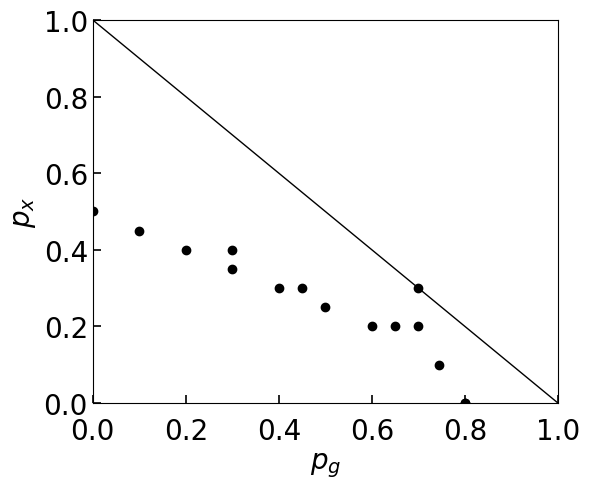

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import make_interp_spline

mpl.rcParams['svg.fonttype'] = 'none'  # テキストをフォントのまま保持

#px fixed
px = np.array([0.0, 0.1, 0.2, 0.3,0.4])
pg = np.array([0.8, 0.745, 0.65, 0.45,0.3])

#pg fixed
px1 = np.array([0.5, 0.45, 0.4, 0.35, 0.3,0.25,0.2])
pg1 = np.array([0.0, 0.1, 0.2, 0.3, 0.4,0.5,0.6])

#pz fixed
px2 = np.array([0.0, 0.2, 0.3])
pg2 = np.array([0.8, 0.7, 0.7])

plt.figure(figsize=(6,5))

plt.plot(pg,  px, 'o', color='black',label='TEE')
plt.plot(pg1, px1,'o', color='black')
plt.plot(pg2, px2,'o', color='black')

pg_grid = np.linspace(0,1,300); plt.plot(pg_grid, 1 - pg_grid, 'k', lw=1)

plt.xlabel(r'$p_g$',fontsize=20)
plt.ylabel(r'$p_x$',fontsize=20)
plt.xlim(0, 1); plt.ylim(0, 1)
#plt.title("phase diagram")
plt.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=6)
plt.tick_params(axis='both', labelsize=20) 
plt.tick_params(axis='x', pad=10)
#plt.legend()
plt.tight_layout()
#plt.savefig(f"fig5.png", dpi=300, bbox_inches='tight')
plt.savefig(f"fig5.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()


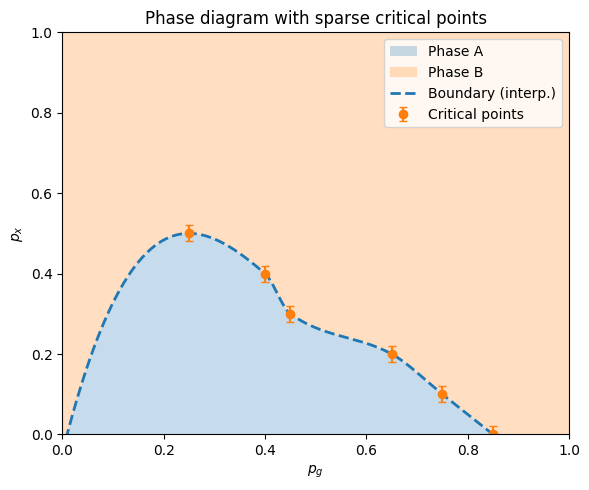

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# === 1) あなたの臨界点を入れてください（例） ===
#    横軸 pg, 縦軸 px
pc_points = np.array([
    [0.85, 0.0],
    [0.75, 0.1],
    [0.65, 0.2],
    [0.45, 0.3],
    [0.4, 0.4],
    [0.25, 0.5],
])
pg_pts = pc_points[:,0]
px_pts = pc_points[:,1]

# （任意）臨界点の不確かさがある場合は上下幅を指定（なければ None）
# 例：±0.02 程度の px 誤差
px_err = np.full_like(px_pts, 0.02)

# === 2) 境界曲線の補間 ===
# pg でソートして単調な補間にする
idx = np.argsort(pg_pts)
pg_pts, px_pts = pg_pts[idx], px_pts[idx]
if px_err is not None:
    px_err = px_err[idx]

# 補間の解像度
pg_grid = np.linspace(0.0, 1.0, 400)

# まずは numpy.interp のシンプル補間（直線分割）
px_grid = np.interp(pg_grid, pg_pts, px_pts)

# SciPy の PCHIP が利用可能なら滑らかに（任意）
try:
    from scipy.interpolate import PchipInterpolator
    px_grid = PchipInterpolator(pg_pts, px_pts)(pg_grid)
except Exception:
    pass  # SciPy が無ければ上の直線補間のまま

# === 3) 図の描画 ===
plt.figure(figsize=(6,5))

# 相の領域塗りつぶし（境界の上下どちらが Phase A/B かは系の定義に合わせて）
# ここでは「境界より下 = Phase A」「上 = Phase B」として塗る例
px_min, px_max = 0.0, 1.0
plt.fill_between(pg_grid, px_min, px_grid, alpha=0.25, label="Phase A")
plt.fill_between(pg_grid, px_grid, px_max, alpha=0.25, label="Phase B")

# 境界線
plt.plot(pg_grid, px_grid, linestyle="--", linewidth=2, label="Boundary (interp.)")

# 離散臨界点（誤差棒つき）
plt.errorbar(pg_pts, px_pts, yerr=px_err, fmt="o", capsize=3, label="Critical points")

# 軸や凡例
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel(r"$p_g$")
plt.ylabel(r"$p_x$")
plt.title("Phase diagram with sparse critical points")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


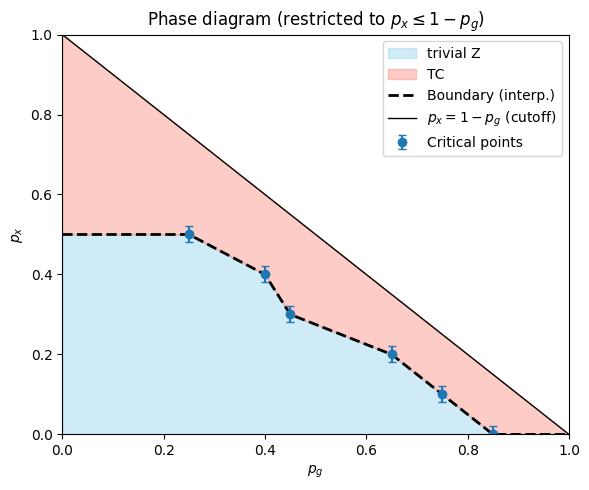

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# === 1) 臨界点データ ===
pc_points = np.array([
    [0.85, 0.0],
    [0.75, 0.1],
    [0.65, 0.2],
    [0.45, 0.3],
    [0.4, 0.4],
    [0.25, 0.5],
])
pg_pts = pc_points[:,0]
px_pts = pc_points[:,1]
px_err = np.full_like(px_pts, 0.02)  # 誤差例（不要なら削除）

# ソートして補間の準備
idx = np.argsort(pg_pts)
pg_pts, px_pts = pg_pts[idx], px_pts[idx]
px_err = px_err[idx]

# 補間曲線
pg_grid = np.linspace(0, 1, 400)
px_grid = np.interp(pg_grid, pg_pts, px_pts)

# === 2) マスク領域 (px <= 1 - pg) ===
pg_mesh, px_mesh = np.meshgrid(pg_grid, np.linspace(0, 1, 400))
mask = px_mesh <= 1 - pg_mesh  # True の部分だけ有効

# === 3) 描画 ===
plt.figure(figsize=(6,5))

# 相の塗り分け（境界より下 = Phase A, 上 = Phase B）
phaseA = (px_mesh < np.interp(pg_mesh[0], pg_pts, px_pts)) & mask

# fill_between を mask に合わせて描く
plt.fill_between(pg_grid, 0, px_grid, 
                 where=(px_grid <= 1 - pg_grid), 
                 color="skyblue", alpha=0.4, label="trivial Z")
plt.fill_between(pg_grid, px_grid, 1 - pg_grid, 
                 where=(px_grid <= 1 - pg_grid), 
                 color="salmon", alpha=0.4, label="TC")

# 境界曲線
plt.plot(pg_grid, px_grid, 'k--', lw=2, label="Boundary (interp.)")

# 臨界点＋誤差棒
plt.errorbar(pg_pts, px_pts, yerr=px_err, fmt="o", capsize=3, label="Critical points")

# 領域制約線 px = 1 - pg
plt.plot(pg_grid, 1 - pg_grid, 'k-', lw=1, label=r"$p_x = 1-p_g$ (cutoff)")

# 軸・凡例
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$p_g$")
plt.ylabel(r"$p_x$")
plt.title("Phase diagram (restricted to $p_x \leq 1-p_g$)")
plt.legend()
plt.tight_layout()
plt.show()


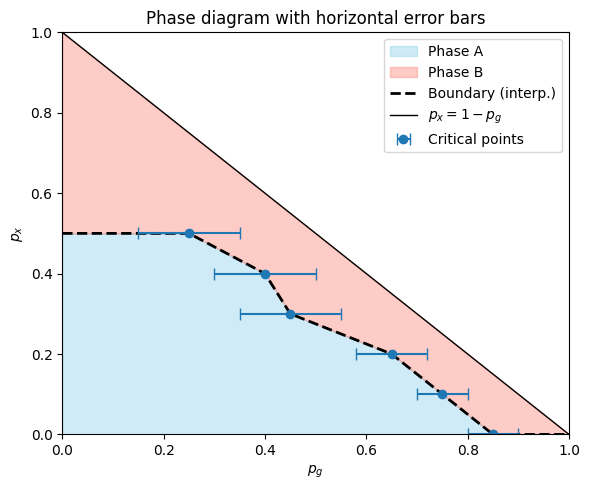

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# === 1) 臨界点データ ===
pc_points = np.array([
    [0.85, 0.0],
    [0.75, 0.1],
    [0.65, 0.2],
    [0.45, 0.3],
    [0.4, 0.4],
    [0.25, 0.5],
])
pg_pts = pc_points[:,0]
px_pts = pc_points[:,1]



# 点ごとの横方向誤差（例としてバラバラに設定）
pg_err = np.array([0.05, 0.05, 0.07, 0.1, 0.1, 0.1])

# === 2) 補間曲線 ===
idx = np.argsort(pg_pts)
pg_pts, px_pts = pg_pts[idx], px_pts[idx]
pg_err = pg_err[idx]

pg_grid = np.linspace(0, 1, 400)
px_grid = np.interp(pg_grid, pg_pts, px_pts)

pg_smooth_lower = spline_lower(px_smooth)

# === 3) 描画 ===
plt.figure(figsize=(6,5))

# 領域制約 px <= 1 - pg に従って塗り分け
plt.fill_between(pg_grid, 0, px_grid,
                 where=(px_grid <= 1 - pg_grid),
                 color="skyblue", alpha=0.4, label="Phase A")
plt.fill_between(pg_grid, px_grid, 1 - pg_grid,
                 where=(px_grid <= 1 - pg_grid),
                 color="salmon", alpha=0.4, label="Phase B")

# 補間した境界線
plt.plot(pg_grid, px_grid, 'k--', lw=2, label="Boundary (interp.)")


# 臨界点 + 横誤差棒
plt.errorbar(pg_pts, px_pts, xerr=pg_err, fmt="o", capsize=4, label="Critical points")

# cutoff 線 (px = 1 - pg)
plt.plot(pg_grid, 1 - pg_grid, 'k-', lw=1, label=r"$p_x = 1-p_g$")

# 軸ラベルなど
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$p_g$")
plt.ylabel(r"$p_x$")
plt.title("Phase diagram with horizontal error bars")
plt.legend()
plt.tight_layout()
plt.show()


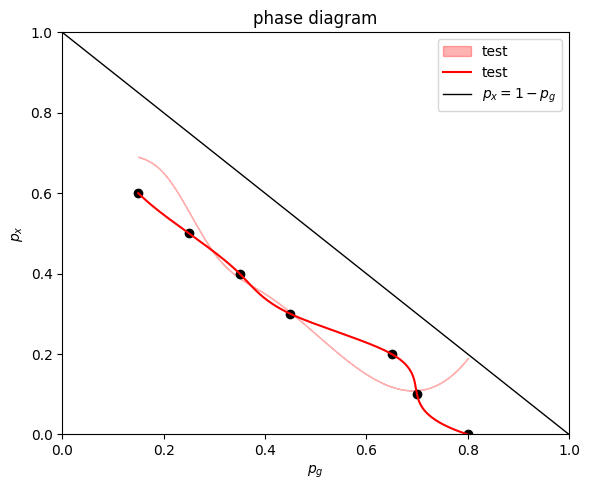

In [34]:
from scipy.interpolate import make_interp_spline

px = np.array([0.0, 0.1, 0.2, 0.3,0.4,0.5,0.6])
pg = np.array([0.8, 0.7, 0.65, 0.45,0.35,0.25,0.15])
#pg_err = np.array([0.00, 0.02, 0.05, 0.05,0.1,0.1,0.2])  # 幅（例）
pg_err = np.array([0.0, 0.0, 0.0, 0.0,0.0,0.0,0.0])  # 幅（例）

# 中央点と誤差
pg_upper = pg + pg_err
pg_lower = pg - pg_err

# 補間（なめらかな曲線に）
px_smooth = np.linspace(px.min(), px.max(), 300)
spline_mid = make_interp_spline(px, pg, k=3)
spline_upper = make_interp_spline(px, pg_upper, k=3)
spline_lower = make_interp_spline(px, pg_lower, k=3)

pg_smooth = spline_mid(px_smooth)
pg_smooth_upper = spline_upper(pg_smooth)
pg_smooth_lower = spline_lower(pg_smooth)

# 描画
plt.figure(figsize=(6, 5))
plt.fill_between(pg_smooth, pg_smooth_lower, pg_smooth_upper, color='red', alpha=0.3, label='test')
plt.plot(pg_smooth, px_smooth,color='red', label='test')

# cutoff 線 (px = 1 - pg)
plt.plot(pg_grid, 1 - pg_grid, 'k-', lw=1, label=r"$p_x = 1-p_g$")

plt.scatter(pg, px, color='black')
plt.xlabel(r'$p_g$')
plt.ylabel(r'$p_x$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("phase diagram")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()